# 무신사 추천순 리뷰 분석
- 무신사 판매금액순 리뷰분석과 동일하게 진행되었습니다.

## 데이터 불러오기 - 추천순 TOP 50 상품 리뷰 분석

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 데이터 불러오기
df_reco_merged = pd.read_csv("recommend_reviews_merged.csv", encoding="utf-8-sig")

# 상위 데이터 확인
print("👀 추천 리뷰 통합 데이터 상위 5개 확인")
display(df_reco_merged.head())

# 데이터 요약 정보 (컬럼명, 데이터 개수, 타입 확인)
print("\n📊 데이터 요약 정보")
df_reco_merged.info()

# 결측치 확인
print("\n🚨 결측치 확인")
print(df_reco_merged.isnull().sum())

👀 추천 리뷰 통합 데이터 상위 5개 확인


,goods_no,review_no,content,grade,option_size,size_feedback,create_date,review_sex,height,weight,...,month,bmi,content_clean,goods_name,sale_price,sale_rate,review_count,review_score,category,size_type
0,6092187,83840402,커브드팬츠 베이지 색상까지 구매했습니다. 스트레이트 핏이 돌아온다고 하지만 아직 널...,5,03.베이지 · 26,정사이즈,2026-04-21 02:59:07+09:00,여성,158.0,59.0,...,4,23.6,커브드팬츠 베이지 색상까지 구매했습니다 스트레이트 핏이 돌아온다고 하지만 아직 널널...,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형
1,6092187,83830897,매우 잘 구겨져서... 주의...ㅠㅠ\n또 여름에 입기에는 더울 것 같아요.\n지금...,4,01.블랙 · 26,조금 큼,2026-04-20 18:50:23+09:00,여성,158.0,54.0,...,4,21.6,매우 잘 구겨져서 주의 ㅠㅠ 또 여름에 입기에는 더울 것 같아요 지금도 덥습니다 ㅎㅎ,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형
2,6092187,83829268,너무 마음에 듭니다. 모양이 화면 그대로 이쁘고 무엇보다 기장이 짧지 않아서 좋고...,5,03.베이지 · 29,정사이즈,2026-04-20 17:33:29+09:00,여성,169.0,59.0,...,4,20.7,너무 마음에 듭니다 모양이 화면 그대로 이쁘고 무엇보다 기장이 짧지 않아서 좋고 매...,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형
3,6092187,83825510,예뻐요 좋아요 아무 옷이나 다 잘 어울려서 부담없이 찾아 입기 좋음,4,24,조금 큼,2026-04-20 14:34:29+09:00,여성,167.0,47.0,...,4,16.9,예뻐요 좋아요 아무 옷이나 다 잘 어울려서 부담없이 찾아 입기 좋음,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형
4,6092187,83820922,보통 하의 m사이즈를 입는데 27주문했더니 너무커서 26으로 교환했어요 그래도 허리...,5,02.크림 · 26,많이 큼,2026-04-20 10:47:52+09:00,NaN,170.0,53.0,...,4,18.3,보통 하의 m사이즈를 입는데 27주문했더니 너무커서 26으로 교환했어요 그래도 허리...,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형



📊 데이터 요약 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21252 entries, 0 to 21251
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   goods_no       21252 non-null  int64  
 1   review_no      21252 non-null  int64  
 2   content        21252 non-null  object 
 3   grade          21252 non-null  int64  
 4   option_size    21252 non-null  object 
 5   size_feedback  4006 non-null   object 
 6   create_date    21252 non-null  object 
 7   review_sex     19595 non-null  object 
 8   height         19298 non-null  float64
 9   weight         19274 non-null  float64
 10  color          1384 non-null   object 
 11  size           21252 non-null  object 
 12  has_grade      21252 non-null  bool   
 13  year           21252 non-null  int64  
 14  month          21252 non-null  int64  
 15  bmi            19195 non-null  float64
 16  content_clean  21252 non-null  object 
 17  goods_name     21252 non-null  object

In [3]:
# 텍스트가 '...'으로 잘리지 않게 설정
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

display(df_reco_merged.head(2))

,goods_no,review_no,content,grade,option_size,size_feedback,create_date,review_sex,height,weight,color,size,has_grade,year,month,bmi,content_clean,goods_name,sale_price,sale_rate,review_count,review_score,category,size_type
0,6092187,83840402,커브드팬츠 베이지 색상까지 구매했습니다. 스트레이트 핏이 돌아온다고 하지만 아직 널널한게 편하네요,5,03.베이지 · 26,정사이즈,2026-04-21 02:59:07+09:00,여성,158.0,59.0,베이지,26,True,2026,4,23.6,커브드팬츠 베이지 색상까지 구매했습니다 스트레이트 핏이 돌아온다고 하지만 아직 널널한게 편하네요,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형
1,6092187,83830897,매우 잘 구겨져서... 주의...ㅠㅠ\n또 여름에 입기에는 더울 것 같아요.\n지금도 덥습니다..ㅎㅎ,4,01.블랙 · 26,조금 큼,2026-04-20 18:50:23+09:00,여성,158.0,54.0,블랙,26,True,2026,4,21.6,매우 잘 구겨져서 주의 ㅠㅠ 또 여름에 입기에는 더울 것 같아요 지금도 덥습니다 ㅎㅎ,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형


In [4]:
# 불필요한 컬럼 리스트 정의
columns_to_drop = [
    'review_sex',   # 우먼즈 브랜드라 의미 없음
    'option_size',  # 이미 size와 color로 분리됨
    'create_date',  # 이미 year와 month로 분리됨
    'content',      # content_clean으로 대체
]

# 컬럼 삭제
df_reco_clean = df_reco_merged.drop(columns=columns_to_drop)

# 정리된 데이터 확인
print("✨ 정제 완료된 추천 리뷰 데이터 구조:")
df_reco_clean.info()

display(df_reco_clean.head(3))

✨ 정제 완료된 추천 리뷰 데이터 구조:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21252 entries, 0 to 21251
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   goods_no       21252 non-null  int64  
 1   review_no      21252 non-null  int64  
 2   grade          21252 non-null  int64  
 3   size_feedback  4006 non-null   object 
 4   height         19298 non-null  float64
 5   weight         19274 non-null  float64
 6   color          1384 non-null   object 
 7   size           21252 non-null  object 
 8   has_grade      21252 non-null  bool   
 9   year           21252 non-null  int64  
 10  month          21252 non-null  int64  
 11  bmi            19195 non-null  float64
 12  content_clean  21252 non-null  object 
 13  goods_name     21252 non-null  object 
 14  sale_price     21252 non-null  int64  
 15  sale_rate      21252 non-null  int64  
 16  review_count   21252 non-null  int64  
 17  review_score   21252 non-nu

,goods_no,review_no,grade,size_feedback,height,weight,color,size,has_grade,year,month,bmi,content_clean,goods_name,sale_price,sale_rate,review_count,review_score,category,size_type
0,6092187,83840402,5,정사이즈,158.0,59.0,베이지,26,True,2026,4,23.6,커브드팬츠 베이지 색상까지 구매했습니다 스트레이트 핏이 돌아온다고 하지만 아직 널널한게 편하네요,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형
1,6092187,83830897,4,조금 큼,158.0,54.0,블랙,26,True,2026,4,21.6,매우 잘 구겨져서 주의 ㅠㅠ 또 여름에 입기에는 더울 것 같아요 지금도 덥습니다 ㅎㅎ,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형
2,6092187,83829268,5,정사이즈,169.0,59.0,베이지,29,True,2026,4,20.7,너무 마음에 듭니다 모양이 화면 그대로 이쁘고 무엇보다 기장이 짧지 않아서 좋고 매우 부드럽습니다 다른 컬러도 추가로 살까 생각 중입니다,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형


## 감성 분석(Sentiment Analysis)

In [5]:
from transformers import pipeline
import torch
import time

# 텍스트 안 잘리게 보기 옵션 (혹시 풀렸을까 봐 다시 적용)
pd.set_option('display.max_colwidth', None)

# GPU 장치 세팅 (RTX 3070 Ti 가동!)
device = 0 if torch.cuda.is_available() else -1

print("✅ 훈련된 실전 감성 분석 전문가 모델 로딩 중...")
sentiment_analyzer = pipeline(
    "text-classification", 
    model="matthewburke/korean_sentiment", 
    device=device
)

print("🚀 df_reco_clean 데이터로 터보 엔진 감성 분석 시작...")
start_time = time.time()

# 💡 핵심: 'content_clean' 컬럼 사용! 
# 혹시 모를 빈칸(NaN)은 빈 문자열로 처리
texts = df_reco_clean['content_clean'].fillna("").astype(str).tolist()

# 배치 처리로 고속 분석
results = sentiment_analyzer(texts, batch_size=64, truncation=True)

# 모델의 결과값을 1(긍정)과 0(부정)으로 치환하여 새로운 컬럼 생성
df_reco_clean['sentiment_confidence'] = [r['score'] for r in results]
df_reco_clean['sentiment_score'] = [1 if res['label'] == 'LABEL_1' else 0 for res in results]

end_time = time.time()
print(f"✅ 감성 분석 완료! 소요 시간: {round((end_time - start_time) / 60, 2)}분")

✅ 훈련된 실전 감성 분석 전문가 모델 로딩 중...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: matthewburke/korean_sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 df_reco_clean 데이터로 터보 엔진 감성 분석 시작...
✅ 감성 분석 완료! 소요 시간: 0.8분


In [6]:
# 결과 확인
print("\n👀 깔끔해진 텍스트와 감성 점수 찰떡궁합 확인하기")
display(df_reco_clean[['content_clean', 'sentiment_score', 'sentiment_confidence', 'grade']].head(10))

# 전체 데이터 중 긍정(1)과 부정(0) 통계 확인
print("\n📊 전체 긍정/부정 비율")
print(df_reco_clean['sentiment_score'].value_counts())


👀 깔끔해진 텍스트와 감성 점수 찰떡궁합 확인하기


,content_clean,sentiment_score,sentiment_confidence,grade
0,커브드팬츠 베이지 색상까지 구매했습니다 스트레이트 핏이 돌아온다고 하지만 아직 널널한게 편하네요,1,0.951150,5
1,매우 잘 구겨져서 주의 ㅠㅠ 또 여름에 입기에는 더울 것 같아요 지금도 덥습니다 ㅎㅎ,1,0.947247,4
2,너무 마음에 듭니다 모양이 화면 그대로 이쁘고 무엇보다 기장이 짧지 않아서 좋고 매우 부드럽습니다 다른 컬러도 추가로 살까 생각 중입니다,1,0.972209,5
3,예뻐요 좋아요 아무 옷이나 다 잘 어울려서 부담없이 찾아 입기 좋음,1,0.973211,4
4,보통 하의 m사이즈를 입는데 27주문했더니 너무커서 26으로 교환했어요 그래도 허리는커요 벨트하면 괜찮아요 날씬해보이고 너무 예뻐서 블랙도 추가구매했어요,1,0.918420,5
5,모델보고 착용한게 예뻐서 샀는데 색도 진하게 예쁘고 핏도 진짜 굿입니다 그리고 부드러워요 입었을때도 편해요,1,0.969260,5
6,핏이 너무 예쁘고 매장에 트렌디한 상품이 많아서 좋았어요 직원들이 친절해요,1,0.973329,5
7,면 100 소재가 좋아요 허리 사이즈 약간 크다는거 감안 1사이즈 했는데도 커요 참고하시길 길이도 약간 손봐야 할 것 같아요,1,0.931369,5
8,일단 핏이 정말 마음에 들고 걍 사계절 내내 기본템으로 잘 입을 것 같아요 아주 만족합니다,1,0.973227,5
9,허리는 얇은데 허벅지가 굵어서 바지 고르기힘든데 이 바지 좋네용 허리는 많이 남는데 핏은 예뻐요,1,0.966745,5



📊 전체 긍정/부정 비율
sentiment_score
1    19854
0     1398
Name: count, dtype: int64


In [7]:
# 신뢰도 점수가 0.7 미만인 헷갈리는 데이터가 있는지 확인
under_0_7 = df_reco_clean[df_reco_clean['sentiment_confidence'] < 0.7]

print(f"🚨 0.7 미만인 데이터 개수: {len(under_0_7)}개")
display(under_0_7.head(5))

🚨 0.7 미만인 데이터 개수: 932개


,goods_no,review_no,grade,size_feedback,height,weight,color,size,has_grade,year,month,bmi,content_clean,goods_name,sale_price,sale_rate,review_count,review_score,category,size_type,sentiment_confidence,sentiment_score
43,6092187,83650150,5,조금 큼,165.0,57.0,블랙,26,True,2026,4,20.9,27구매했다가 허리가 골반까지 내려와서 속옷도 보일 수준이라 26으로 바꿨어요 내려입는 거 좋아하면 정사이즈 적당히 맞게 입고 싶으면 한사이즈 작게 시키는 거 추천해요 핏 예쁘고 과한 벌룬핏이 아니라서 좋아요,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형,0.552759,0
63,6092187,83563914,5,정사이즈,164.0,65.0,블랙,29,True,2026,4,24.2,출근룩으로 데일리로 휘뚜루마뚜루 입을수있음 깔끔하고 신축성이 없어 여유롭게 입고 싶으면 한사이즈 업해도 무리 없을 듯,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형,0.507273,1
244,6092187,82896976,4,조금 작음,171.0,64.0,NaN,29,True,2026,3,21.9,생각보다 면이 더 얇아서 겨울엔 추워서 못입어요 상세 사이즈보다 실 사이즈가 좀 작은듯해요,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형,0.533224,1
291,6092187,82738626,5,조금 큼,165.0,150.0,NaN,28,True,2026,3,55.1,다좋은데 생각보다 주름이 잘지는 편입니다 적당한 두께감에 한여름아니면 갠춘,[한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors),47410,5,386,96,하의,숫자형,0.615494,1
393,6121801,83639256,5,조금 작음,175.0,70.0,페일 그린,M,True,2026,4,22.9,어머니가 새로 구매해보셨는데 생각보다 사이즈가 작다고 하시네요,우먼즈 시어 슬림 티셔츠 (5 colors),15100,5,11,86,상의,문자형,0.582728,0


## 텍스트 임베딩 (Text Embedding)

In [8]:
from sentence_transformers import SentenceTransformer
import time

# 한국어 문장 임베딩에 특화된 최고 성능 모델 로딩 (GPU 자동 할당)
print("🧠 문장 임베딩 모델 로딩 중...")
embedder = SentenceTransformer('jhgan/ko-sroberta-multitask')

print("🚀 텍스트 임베딩 시작 (문장을 숫자로 변환 중)...")
start_time = time.time()

# 분석할 텍스트 리스트화
texts = df_reco_clean['content_clean'].fillna("").tolist()

# 임베딩 진행 (show_progress_bar=True 옵션으로 진행률을 바(Bar) 형태로 볼 수 있습니다)
embeddings = embedder.encode(texts, show_progress_bar=True)

end_time = time.time()
print(f"✅ 임베딩 완료! 소요 시간: {round((end_time - start_time) / 60, 2)}분")

# 임베딩 데이터 형태(Shape) 확인
print(f"\n📊 생성된 임베딩 형태: {embeddings.shape}")
print("👉 해석: {}개의 리뷰가 각각 {}차원의 숫자(벡터)로 완벽하게 변환되었습니다.".format(embeddings.shape[0], embeddings.shape[1]))

# 💡 임베딩 데이터 안전하게 백업하기
# 나중에 주피터 노트북 커널이 끊겨도 다시 2~3분을 기다릴 필요 없이 파일만 불러오면 됩니다.
np.save('reco_embeddings_backup.npy', embeddings)
print("💾 임베딩 결과를 'reco_embeddings_backup.npy' 파일로 안전하게 저장했습니다!")

🧠 문장 임베딩 모델 로딩 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 텍스트 임베딩 시작 (문장을 숫자로 변환 중)...


Batches:   0%|          | 0/665 [00:00<?, ?it/s]

✅ 임베딩 완료! 소요 시간: 0.33분

📊 생성된 임베딩 형태: (21252, 768)
👉 해석: 21252개의 리뷰가 각각 768차원의 숫자(벡터)로 완벽하게 변환되었습니다.
💾 임베딩 결과를 'reco_embeddings_backup.npy' 파일로 안전하게 저장했습니다!


## 고객 군집화 (K-Means Clustering)

In [9]:
from sklearn.cluster import KMeans

# K-Means 모델 설정 (고객 군집을 4개로 설정)
print("🤖 K-Means 클러스터링 시작 (K=4)...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# 임베딩 데이터 학습 및 군집 예측
# 방금 만든 embeddings 변수(768차원 숫자)를 그대로 집어넣습니다.
clusters = kmeans.fit_predict(embeddings)

# 결과를 원본 데이터프레임에 새로운 기둥(컬럼)으로 추가
df_reco_clean['cluster'] = clusters
print("✅ 클러스터링 완료! 각 리뷰에 0~3번 군집 꼬리표가 붙었습니다.")

# 군집별로 데이터가 몇 개씩 묶였는지 밸런스 확인
print("\n📊 군집별 리뷰 개수:")
print(df_reco_clean['cluster'].value_counts().sort_index())

# 💡 핵심: 4개의 군집이 각각 어떤 특징으로 묶였는지 샘플 엿보기
print("\n👀 군집별 텍스트 샘플 확인 (어떤 주제끼리 묶였을까?)")
for i in range(4):
    print(f"\n▶ [Cluster {i}] 샘플 3개:")
    # 각 군집에서 무작위로 3개씩만 뽑아서 보여줍니다.
    sample_texts = df_reco_clean[df_reco_clean['cluster'] == i]['content_clean'].sample(3, random_state=42)
    for text in sample_texts:
        print(f" - {text}")

🤖 K-Means 클러스터링 시작 (K=4)...
✅ 클러스터링 완료! 각 리뷰에 0~3번 군집 꼬리표가 붙었습니다.

📊 군집별 리뷰 개수:
cluster
0    5275
1    5467
2    6561
3    3949
Name: count, dtype: int64

👀 군집별 텍스트 샘플 확인 (어떤 주제끼리 묶였을까?)

▶ [Cluster 0] 샘플 3개:
 - 요즘 유행하는 커브드 핏을 무신사 스탠다드에서 합리적인 가격에 잘 뽑은 것 같아요 블랙이라 어디든 잘 어울리고 클래식한 니트나 가디건이랑 매치하면 깔끔하면서도 센스 있어 보여서 출근룩으로도 자주 손이 갑니다 소재가 톡톡해서 사계절 내내 잘 입을 것 같네요
 - 휘뚜루마뚜루 편하게 입고다닐수 있아서 좋아요
 - 출근용으로 샀는데 너무 벙벙하지 않고 좋습니다

▶ [Cluster 1] 샘플 3개:
 - 재질도 좋고 사이즈도 적당합니다 나중에 또 살거같아요
 - 동일한 제품 있는데 실수로 건조기 돌렸더니 작아져서 다시 구매했습니다 입다가 헤지면 또 다시 구매할 것 같아요 핏이 깔끔하고 좋습니다
 - 생각보다 핏도 괜찮고 좋네요 마음에 쏙 듭니당 다른색도 구매할려구요

▶ [Cluster 2] 샘플 3개:
 - 밴딩이라 허리 낙낙하고 와이드 핏이라 슬랙스여도 다양하게 매치할 수 있어요
 - 핏이 좀 안예뻐요 일단 엉덩이 큰 사람들은 엉덩이가 껴서 피해여할 것 같고 엉덩이는 끼는데 다른곳은 다 커서 애매합니다 키가 큰 편이면 길이도 짧아요 질은 좋습니다
 - 핀턱이 잡혀있어서 다리도 길어보이고 얇아보이는 효과가 있었어요

▶ [Cluster 3] 샘플 3개:
 - 셔츠 입을 때 안에 이너로 입기 딱이에요 두께감도 적당합니다
 - 사이즈 좋고 핏 괜찮게 빠졌어요 데일리하게 어디든 코디하기 좋은 바지 입니다 물 빠짐 없길 바랍니다
 - 딱 깔끔한 정석 와이드핏 슬랙스에요 두께감도 너무 얇지는 않고 급하게 필요해서 구매했는데 앞으로도 휘뚜루 마뚜루 잘 입을 것 같아요


In [10]:
print("👀 군집별 텍스트 샘플 10개씩 꼼꼼하게 확인하기")

for i in range(4):
    print(f"\n{'='*80}")
    print(f"▶ [Cluster {i}] 샘플 10개 (어떤 특징의 고객들일까요?)")
    print(f"{'='*80}")
    
    cluster_data = df_reco_clean[df_reco_clean['cluster'] == i]['content_clean']
    sample_size = min(10, len(cluster_data))
    
    sample_texts = cluster_data.sample(sample_size, random_state=42)
    
    for idx, text in enumerate(sample_texts, 1):
        print(f" {idx}. {text}\n")

👀 군집별 텍스트 샘플 10개씩 꼼꼼하게 확인하기

▶ [Cluster 0] 샘플 10개 (어떤 특징의 고객들일까요?)
 1. 요즘 유행하는 커브드 핏을 무신사 스탠다드에서 합리적인 가격에 잘 뽑은 것 같아요 블랙이라 어디든 잘 어울리고 클래식한 니트나 가디건이랑 매치하면 깔끔하면서도 센스 있어 보여서 출근룩으로도 자주 손이 갑니다 소재가 톡톡해서 사계절 내내 잘 입을 것 같네요

 2. 휘뚜루마뚜루 편하게 입고다닐수 있아서 좋아요

 3. 출근용으로 샀는데 너무 벙벙하지 않고 좋습니다

 4. 쫀쫀하니 퀄리티가 좋아요 이너로도 단독으로도 잘 입을것같아요

 5. 밑단 쪼일수도 있고 편하고 귀욥네요 무릎 디테일도 귀엽고 만족합니당

 6. 넉넉한 크기에 소재가 부드러워서 맘에 들어요 착용할때 편해서 굿

 7. 무엇보다 사이즈 조절할 수 있어서 매우 좋습니다 밥 먹고 나서 간편하게 사이즈 조절과 민망하게 단추를 풀어놓는 것을 누군가 알아차리지 못하는 점이 좋다

 8. 편하고 부드럽고 착용감이 좋아요 재구매 의사 있어요

 9. 가성비를 떠나서 입으면 핏이 진짜 진짜 너무 예뻐요

 10. 핏도 예쁘고 기장이랑 다 좋아요 편하기도 하고 색감이랑 재질도 괜찮은거 같습니다 다음에도 다른 색상으로 구매하고 싶어요


▶ [Cluster 1] 샘플 10개 (어떤 특징의 고객들일까요?)
 1. 재질도 좋고 사이즈도 적당합니다 나중에 또 살거같아요

 2. 동일한 제품 있는데 실수로 건조기 돌렸더니 작아져서 다시 구매했습니다 입다가 헤지면 또 다시 구매할 것 같아요 핏이 깔끔하고 좋습니다

 3. 생각보다 핏도 괜찮고 좋네요 마음에 쏙 듭니당 다른색도 구매할려구요

 4. 사이즈 업업해서 구매했는데 안했음 클날뻔 했습니다 ㅎㅎ 길이가 넘 길어서 접어입을지 세탁소 갈지 고민좀 해야겠어요

 5. 총기장때문에 32 재입고 알림해놓고 기다렸는데 알림 오자마자 구매했네요 쨍한 청이 입고팠는데 생각한 색상 그대로라 마음에 쏙 듭니다

 6. 카고바지 하나쯤 있으면 너무 편할거같으

### 엘보우 메서드

🔍 최적의 군집 수(K)를 찾기 위한 엘보우(Elbow) 분석 시작...
(768차원의 방대한 데이터로 여러 번 군집화를 시도하므로 1~3분 정도 소요됩니다!)
✅ 분석 완료! 엘보우 그래프를 그립니다.


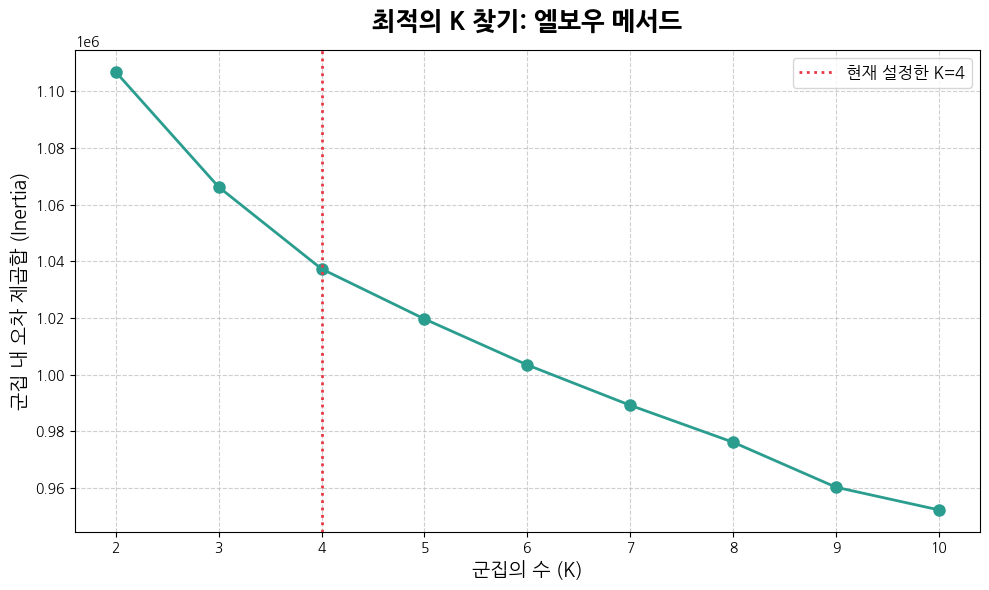

In [11]:
from sklearn.cluster import KMeans

print("🔍 최적의 군집 수(K)를 찾기 위한 엘보우(Elbow) 분석 시작...")
print("(768차원의 방대한 데이터로 여러 번 군집화를 시도하므로 1~3분 정도 소요됩니다!)")

# K를 2부터 10까지 테스트
k_range = range(2, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(embeddings)
    inertias.append(kmeans.inertia_) # inertia_: 군집 내 오차 제곱합(SSE)

print("✅ 분석 완료! 엘보우 그래프를 그립니다.")

# 엘보우 그래프 시각화
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='-', color='#2A9D8F', linewidth=2, markersize=8)

# 차트 디자인
plt.title('최적의 K 찾기: 엘보우 메서드', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('군집의 수 (K)', fontsize=14)
plt.ylabel('군집 내 오차 제곱합 (Inertia)', fontsize=14)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)

# 설정했던 K=4 지점에 강조 표시
plt.axvline(x=4, color='#E63946', linestyle=':', linewidth=2, label='현재 설정한 K=4')
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### 실루엣 스코어 & 데이비스-볼딘 지수

📏 정밀 군집 평가 지표 계산 중 (1~2분 소요될 수 있습니다)...
✅ 계산 완료! 비교 그래프를 그립니다.


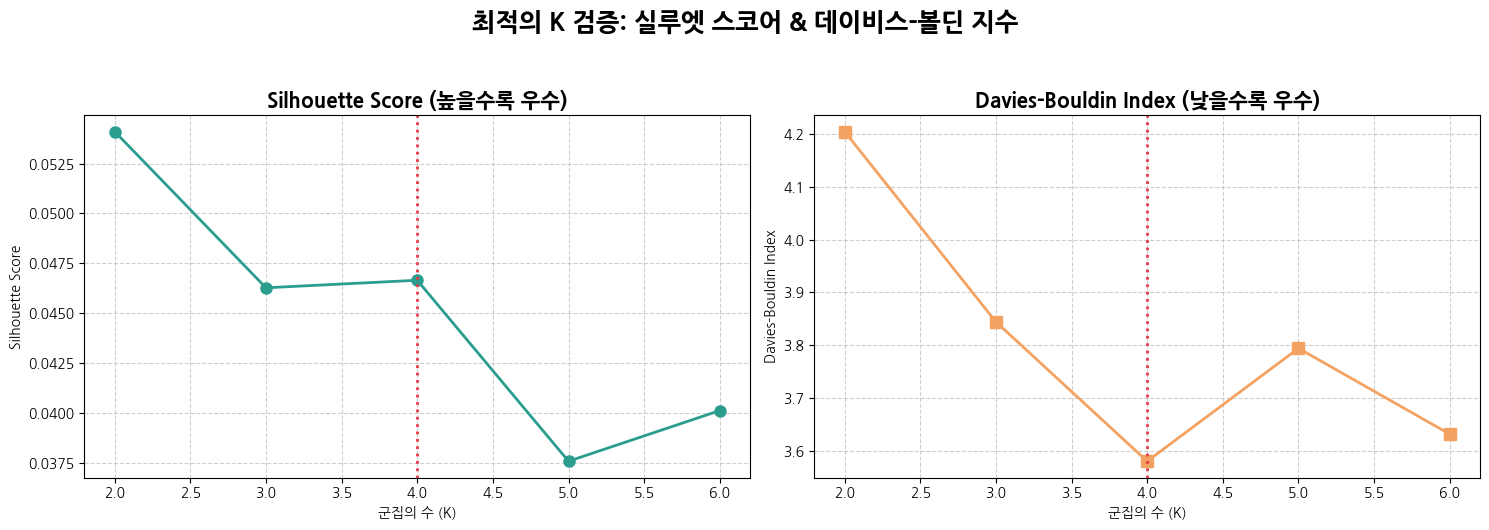

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

print("📏 정밀 군집 평가 지표 계산 중 (1~2분 소요될 수 있습니다)...")

k_range = range(2, 7)
silhouette_scores = []
db_scores = []

for k in k_range:
    # 군집화 진행
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(embeddings)
    
    # 실루엣 스코어 (높을수록 좋음)
    sil_score = silhouette_score(embeddings, labels)
    silhouette_scores.append(sil_score)
    
    # 데이비스-볼딘 지수 (낮을수록 좋음)
    db_score = davies_bouldin_score(embeddings, labels)
    db_scores.append(db_score)

print("✅ 계산 완료! 비교 그래프를 그립니다.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# [왼쪽] 실루엣 스코어 그래프 (높을수록 좋음)
axes[0].plot(k_range, silhouette_scores, marker='o', color='#2A9D8F', linewidth=2, markersize=8)
axes[0].set_title('Silhouette Score (높을수록 우수)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('군집의 수 (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].axvline(x=4, color='#E63946', linestyle=':', linewidth=2) # K=4 강조
axes[0].grid(True, linestyle='--', alpha=0.6)

# [오른쪽] 데이비스-볼딘 지수 그래프 (낮을수록 좋음)
axes[1].plot(k_range, db_scores, marker='s', color='#F4A261', linewidth=2, markersize=8)
axes[1].set_title('Davies-Bouldin Index (낮을수록 우수)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('군집의 수 (K)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].axvline(x=4, color='#E63946', linestyle=':', linewidth=2) # K=4 강조
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('최적의 K 검증: 실루엣 스코어 & 데이비스-볼딘 지수', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 군집별 핵심 키워드 추출 (Keyword Extraction)

### Kiwi 형태소 분석기

In [13]:
# Kiwi 설치
!pip install kiwipiepy

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from kiwipiepy import Kiwi

print("🥝 Kiwi 형태소 분석기 로딩 (명사 + 형용사 + 동사 추출 모드)...")
kiwi = Kiwi()

def extract_core_words_clean(text):
    if not isinstance(text, str) or not text.strip():
        return []
        
    tokens = kiwi.tokenize(text)
    result = []
    
    for token in tokens:
        # 명사 추출
        if token.tag.startswith('N'):
            result.append(token.form)
        
        # 형용사/동사 추출
        elif token.tag in ['VA', 'VV']:
            result.append(token.lemma)
            
    # 불용어(Stopwords) 필터링
    stop_words = [
        # 무의미한 명사들
        '것', '수', '이', '거', '저', '요', '때', '좀', '옷', '구매', '생각', '정도', '마음', '제', '나', '주문',
        '진짜', '너무', '그냥', '조금', '약간', '듯', '편', '때문', '건', '많이','상품', '느낌', '사용', '정말',
        # 무의미하거나 너무 뻔한 동사/형용사들
        '하다', '있다', '없다', '같다', '되다', '않다', '좋다', '사다', '입다', '보다', 
        '들다', '맞다', '이다', '아니다', '가다', '오다', '나오다', '주다', '받다', '모르다',
        # 추가 키워드
        '예쁘다', '이쁘다', '좋다', '만족', '괜찮다', '추천',
        '사이즈', '편하다', '색', '색상', '기본', '하나', '이번', 
        '작년', '이거', '여기저기', '요즘', '어디', '최고', '처음', '사진', '리뷰'
    ]
    
    # 한 글자짜리 단어 중에서도 의미 없는 것들(예: '핏', '품', '색'은 살리고 나머진 제거)을 걸러내는 로직 추가
    final_words = []
    for w in result:
        if w not in stop_words:
            # 1글자인데 우리가 원하는 핵심 패션 단어가 아니면 버림
            if len(w) == 1 and w not in ['품', '색', '질', '목', '팔', '통']:
                continue
            final_words.append(w)
            
    return final_words
print("🥝 Kiwi 형태소 분석기 완료")

🥝 Kiwi 형태소 분석기 로딩 (명사 + 형용사 + 동사 추출 모드)...
🥝 Kiwi 형태소 분석기 완료


### TF-IDF

In [15]:
print("📊 TF-IDF 기반 군집별 Top 20 핵심 키워드 추출 시작...")

vectorizer = TfidfVectorizer(tokenizer=extract_core_words_clean, max_features=500)
top_keywords_dict = {}

for i in range(4):
    
    cluster_texts = df_reco_clean[df_reco_clean['cluster'] == i]['content_clean']
    
    if not cluster_texts.empty:
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)
        words = vectorizer.get_feature_names_out()
        word_scores = np.array(tfidf_matrix.sum(axis=0)).flatten()
        top_indices = word_scores.argsort()[-20:][::-1]
        top_keywords_dict[f'Cluster {i}'] = [words[idx] for idx in top_indices]

df_top_keywords = pd.DataFrame(top_keywords_dict)
df_top_keywords.index = [f'Rank {i}' for i in range(1, 21)]

print("\n✨ [명사+형용사+동사] 군집별 핵심 키워드 Top 20 ✨")
display(df_top_keywords)

📊 TF-IDF 기반 군집별 Top 20 핵심 키워드 추출 시작...


c:\Users\master\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✨ [명사+형용사+동사] 군집별 핵심 키워드 Top 20 ✨


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Rank 1,바지,크다,허리,여름
Rank 2,재질,매장,크다,얇다
Rank 3,배송,바지,길다,재질
Rank 4,빠르다,블랙,바지,바지
Rank 5,길이,가격,길이,두께
Rank 6,어울리다,신사,기장,소재
Rank 7,가격,세일,작다,가을
Rank 8,디자인,작다,보이다,이너
Rank 9,허리,구입,수선,겨울
Rank 10,가성비,배송,짧다,다니다


### 워드클라우드

☁️ 추천순 리뷰 워드클라우드 생성 중...


c:\Users\master\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


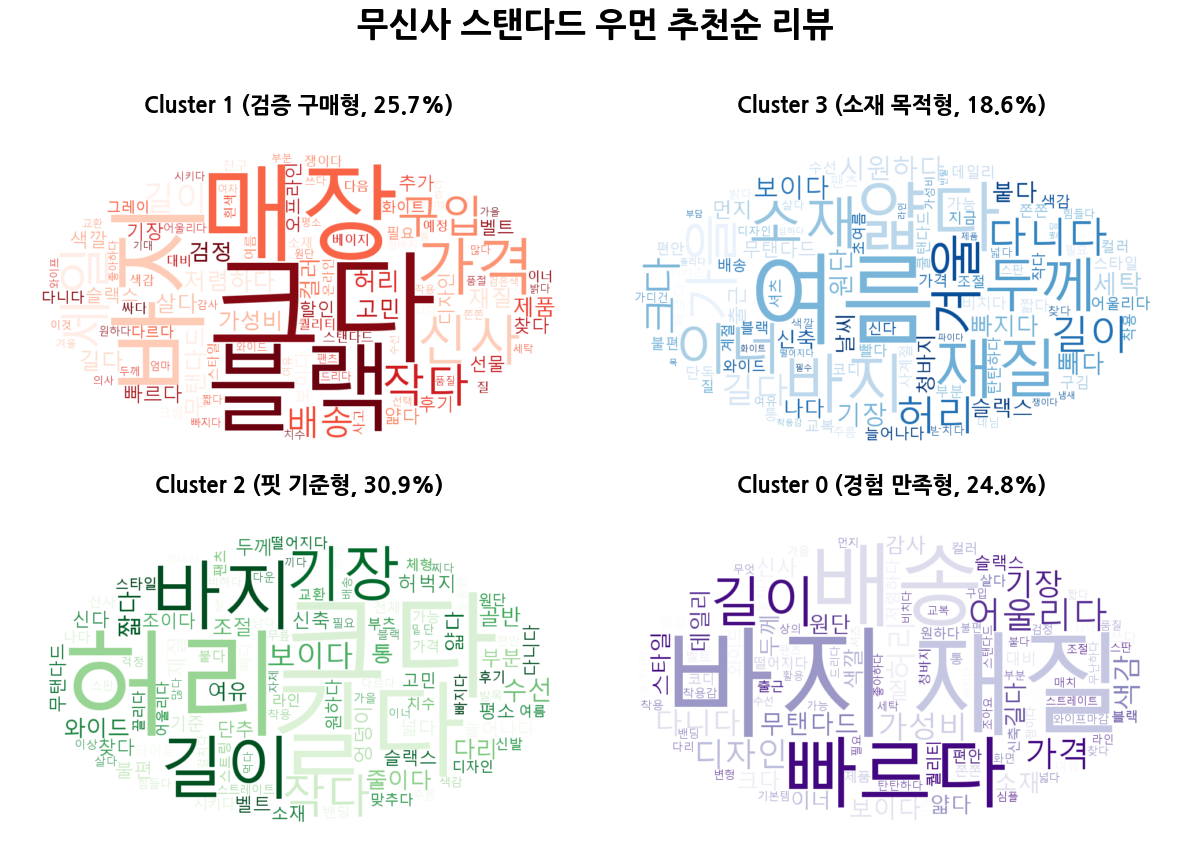

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

print("☁️ 추천순 리뷰 워드클라우드 생성 중...")

# 윈도우 기본 한글 폰트 경로 
font_path = 'C:/Windows/Fonts/malgun.ttf'

# 가로 1000, 세로 600짜리 하얀색(255) 도화지 생성
mask_image = Image.new('L', (1000, 600), 255)
draw = ImageDraw.Draw(mask_image)

# 도화지 가운데에 까만색(0) 타원 그리기
draw.ellipse((50, 50, 950, 550), fill=0)

# 그림을 넘파이 배열로 변환하여 마스크로 준비
oval_mask = np.array(mask_image)
# ==========================================

layout_order = [1, 3, 2, 0] 

cluster_titles = [
    'Cluster 1 (검증 구매형, 25.7%)',   
    'Cluster 3 (소재 목적형, 18.6%)', 
    'Cluster 2 (핏 기준형, 30.9%)', 
    'Cluster 0 (경험 만족형, 24.8%)'      
]

colormaps = ['Reds', 'Blues', 'Greens', 'Purples']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

plt.suptitle('무신사 스탠다드 우먼 추천순 리뷰', fontsize=24, fontweight='bold', y=0.98)

for i, cluster_num in enumerate(layout_order):
    cluster_texts = df_reco_clean[df_reco_clean['cluster'] == cluster_num]['content_clean']
    
    if not cluster_texts.empty:
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)
        words = vectorizer.get_feature_names_out()
        word_scores = np.array(tfidf_matrix.sum(axis=0)).flatten()
        
        word_score_dict = dict(zip(words, word_scores))
        
        wc = WordCloud(
            font_path=font_path,
            width=1000, height=600, 
            background_color='white',
            colormap=colormaps[i], 
            mask=oval_mask,         # ✨ 타원형 틀 씌우기
            contour_width=0,        # ✨ 깔끔하게 테두리 선 없애기
            max_words=100 
        ).generate_from_frequencies(word_score_dict)
        
        axes[i].imshow(wc, interpolation='bilinear')
        
        axes[i].set_title(cluster_titles[i], fontsize=16, fontweight='bold', pad=10)
        axes[i].axis('off') 

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## UMAP 차원 축소 및 시각화

🌌 추천순 리뷰 데이터를 2차원 지도로 압축하며 컬러를 맞추는 중...


c:\Users\master\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


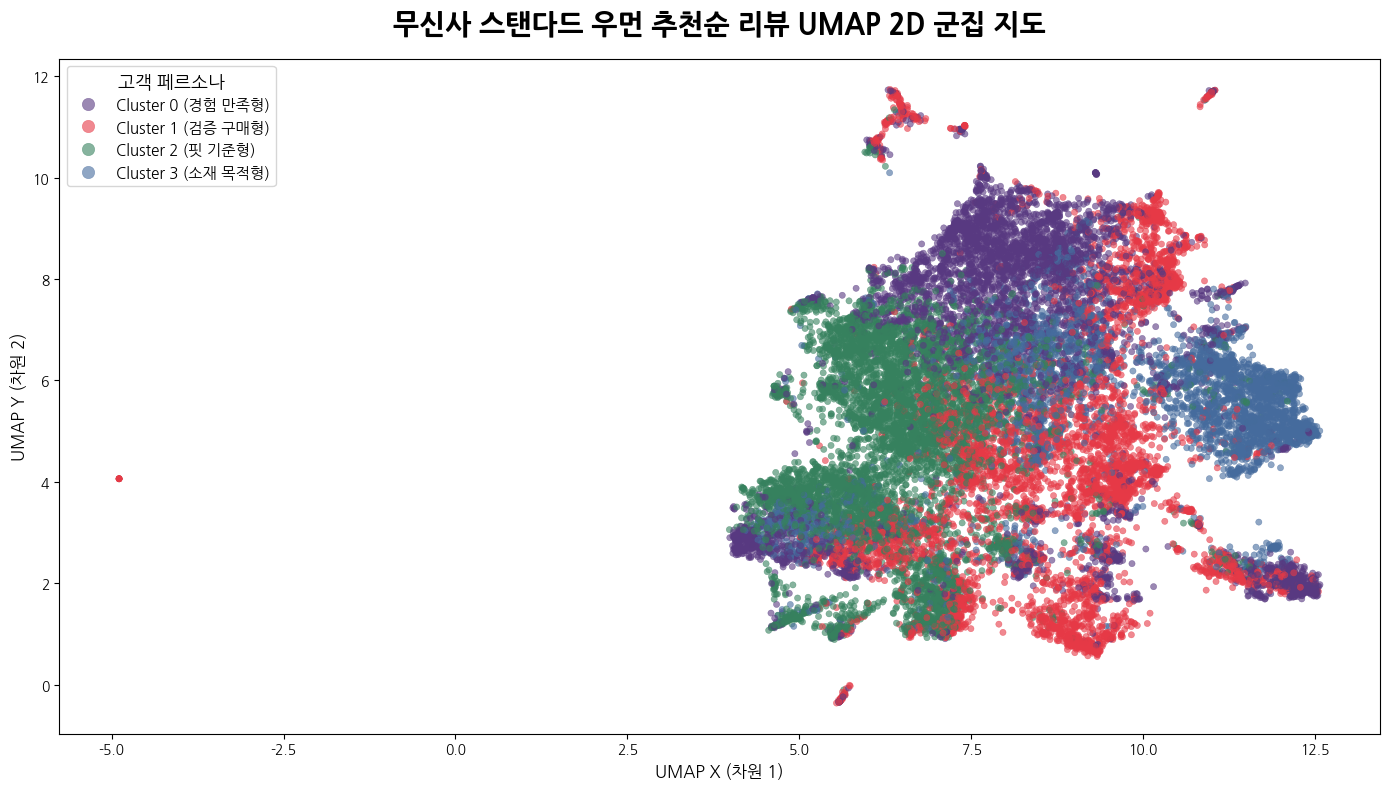

In [17]:
# !pip install umap-learn seaborn

import umap.umap_ as umap
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("🌌 추천순 리뷰 데이터를 2차원 지도로 압축하며 컬러를 맞추는 중...")

# UMAP 모델 설정 및 차원 축소
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_result = reducer.fit_transform(embeddings)

df_reco_clean['umap_x'] = umap_result[:, 0]
df_reco_clean['umap_y'] = umap_result[:, 1]

cluster_names = {
    0: 'Cluster 0 (경험 만족형)',  # 보라색 예정
    1: 'Cluster 1 (검증 구매형)',  # 빨간색 예정
    2: 'Cluster 2 (핏 기준형)',   # 초록색 예정
    3: 'Cluster 3 (소재 목적형)'  # 파란색 예정
}
df_reco_clean['persona'] = df_reco_clean['cluster'].map(cluster_names)

# 시각화 세팅
plt.figure(figsize=(14, 8))

palette = ["#583981", "#E63946", "#36815E", "#456B9D"]

sns.scatterplot(
    x='umap_x', 
    y='umap_y', 
    hue='persona', 
    hue_order=[cluster_names[0], cluster_names[1], cluster_names[2], cluster_names[3]], 
    palette=palette,
    data=df_reco_clean, 
    s=20,          
    alpha=0.6,     
    edgecolor=None 
)

# 차트 꾸미기
plt.title('무신사 스탠다드 우먼 추천순 리뷰 UMAP 2D 군집 지도', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('UMAP X (차원 1)', fontsize=12)
plt.ylabel('UMAP Y (차원 2)', fontsize=12)

# 범례(Legend) 디자인 수정
plt.legend(title='고객 페르소나', title_fontsize='13', fontsize='11', loc='best', markerscale=2)

plt.tight_layout()
plt.show()

## 군집별 긍정/부정(감성분석) 비율 시각화

📊 추천순 리뷰: 페르소나별 감성(불만) 비율 교차 분석 중...

[👀 추천순 페르소나별 긍정/부정 비율(%)]


sentiment_score,0,1
persona,,
Cluster 0 (경험 만족형),0.4,99.6
Cluster 1 (검증 구매형),4.8,95.2
Cluster 2 (핏 기준형),12.5,87.5
Cluster 3 (소재 목적형),7.4,92.6


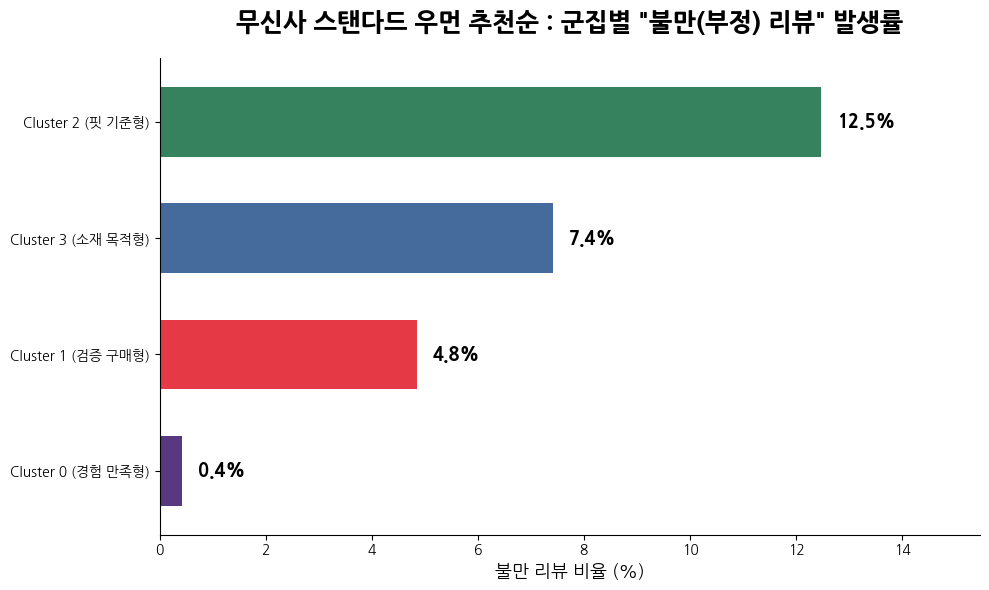

In [18]:
print("📊 추천순 리뷰: 페르소나별 감성(불만) 비율 교차 분석 중...")

reco_cluster_names = {
    0: 'Cluster 0 (경험 만족형)',   # 보라색
    1: 'Cluster 1 (검증 구매형)',   # 빨간색
    2: 'Cluster 2 (핏 기준형)',     # 초록색
    3: 'Cluster 3 (소재 목적형)'    # 파란색
}

df_reco_clean['persona'] = df_reco_clean['cluster'].map(reco_cluster_names)

# 페르소나별 긍정(1)/부정(0) 리뷰 개수 집계
sentiment_counts = df_reco_clean.groupby(['persona', 'sentiment_score']).size().unstack(fill_value=0)

# 개수를 전체 100% 기준의 '비율(%)'로 변환
sentiment_ratio = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

# 데이터프레임으로 수치 먼저 확인
print("\n[👀 추천순 페르소나별 긍정/부정 비율(%)]")
display(sentiment_ratio.round(1))

# sentiment_ratio 데이터에서 부정(0) 비율만 쏙 뽑아서 오름차순 정렬 
negative_ratio = sentiment_ratio[0].sort_values(ascending=True)

color_map = {
    'Cluster 0 (경험 만족형)': '#583981',      # 보라
    'Cluster 1 (검증 구매형)': '#E63946',    # 빨강
    'Cluster 2 (핏 기준형)': '#36815E', # 초록
    'Cluster 3 (소재 목적형)': '#456B9D'  # 파랑
}
# 오름차순 정렬된 순서에 맞게 색상 리스트 생성
colors = [color_map[name] for name in negative_ratio.index]

# 가로 막대 그래프 그리기
plt.figure(figsize=(10, 6))
ax = negative_ratio.plot(kind='barh', color=colors, width=0.6)

# 차트 제목 및 라벨 꾸미기
plt.title('무신사 스탠다드 우먼 추천순 : 군집별 "불만(부정) 리뷰" 발생률', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('불만 리뷰 비율 (%)', fontsize=13)
plt.ylabel('') 

# 막대 '바깥쪽'에 깔끔하게 숫자 달기
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.3, 
             p.get_y() + p.get_height()/2, 
             f'{width:.1f}%', 
             ha='left', va='center', fontsize=13, fontweight='bold', color='black')

# 글자가 잘리지 않도록 X축의 최대 길이를 살짝 늘려줍니다.
plt.xlim(0, negative_ratio.max() + 3)

# 차트 테두리 정리 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()